In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score


In [8]:
df = pd.read_csv("Credit_Card_Dataset.csv")

In [13]:
df.head()

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Annual_Income,Credit_Score,Number_of_Credit_Lines,Credit_Utilization_Ratio,...,Total_Spend_Last_Year,Defaulted,CLV,Total_Transactions,Avg_Transaction_Amount,Max_Transaction_Amount,Min_Transaction_Amount,Fraud_Transactions,Unique_Merchant_Categories,Unique_Transaction_Cities
0,CUST_00001,59,Male,Married,PhD,Unemployed,41442,642,4,0.44,...,13997,0,57310,22,454.337273,1379.89,11.83,0,10,13
1,CUST_00002,49,Male,Divorced,High School,Unemployed,85992,665,7,0.52,...,27768,0,124494,22,378.365000,1939.47,7.00,1,8,13
2,CUST_00003,35,Male,Married,Bachelor,Employed,58420,683,8,0.88,...,17979,1,46180,10,437.929000,1712.14,1.92,0,7,9
3,CUST_00004,63,Male,Single,Bachelor,Employed,59733,674,7,0.40,...,13261,1,35120,23,540.463913,2095.41,16.57,0,9,15
4,CUST_00005,28,Female,Married,Master,Employed,69487,733,5,0.88,...,23562,1,24310,16,520.643750,2068.37,28.06,1,8,12


In [17]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Marital_Status', 'Education_Level',
       'Employment_Status', 'Annual_Income', 'Credit_Score',
       'Number_of_Credit_Lines', 'Credit_Utilization_Ratio',
       'Debt_To_Income_Ratio', 'Number_of_Late_Payments', 'Tenure_in_Years',
       'Total_Transactions_Last_Year', 'Total_Spend_Last_Year', 'Defaulted',
       'CLV', 'Total_Transactions', 'Avg_Transaction_Amount',
       'Max_Transaction_Amount', 'Min_Transaction_Amount',
       'Fraud_Transactions', 'Unique_Merchant_Categories',
       'Unique_Transaction_Cities'],
      dtype='object')

In [18]:
def assign_risk(row):

    if row["Defaulted"] == 1 or row["Credit_Score"] < 560:
        return 2  # High Risk

    elif row["Credit_Score"] < 650 or row["Number_of_Late_Payments"] >= 2:
        return 1  # Medium Risk

    else:
        return 0  # Low Risk


In [19]:
df["Risk_Level"] = df.apply(assign_risk, axis=1)


In [20]:
features = [
    "Annual_Income",
    "Credit_Score",
    "Number_of_Credit_Lines",
    "Credit_Utilization_Ratio",
    "Debt_To_Income_Ratio",
    "Number_of_Late_Payments",
    "Total_Spend_Last_Year",
    "Avg_Transaction_Amount",
    "Max_Transaction_Amount"
]

X = df[features]
y = df["Risk_Level"]


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [22]:
# model = DecisionTreeClassifier(
#     max_depth=4,
#     min_samples_leaf=50,
#     random_state=42
# )
model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [23]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6825
              precision    recall  f1-score   support

           0       0.72      0.96      0.83       508
           1       0.68      0.82      0.74       761
           2       0.62      0.35      0.44       731

    accuracy                           0.68      2000
   macro avg       0.67      0.71      0.67      2000
weighted avg       0.67      0.68      0.66      2000



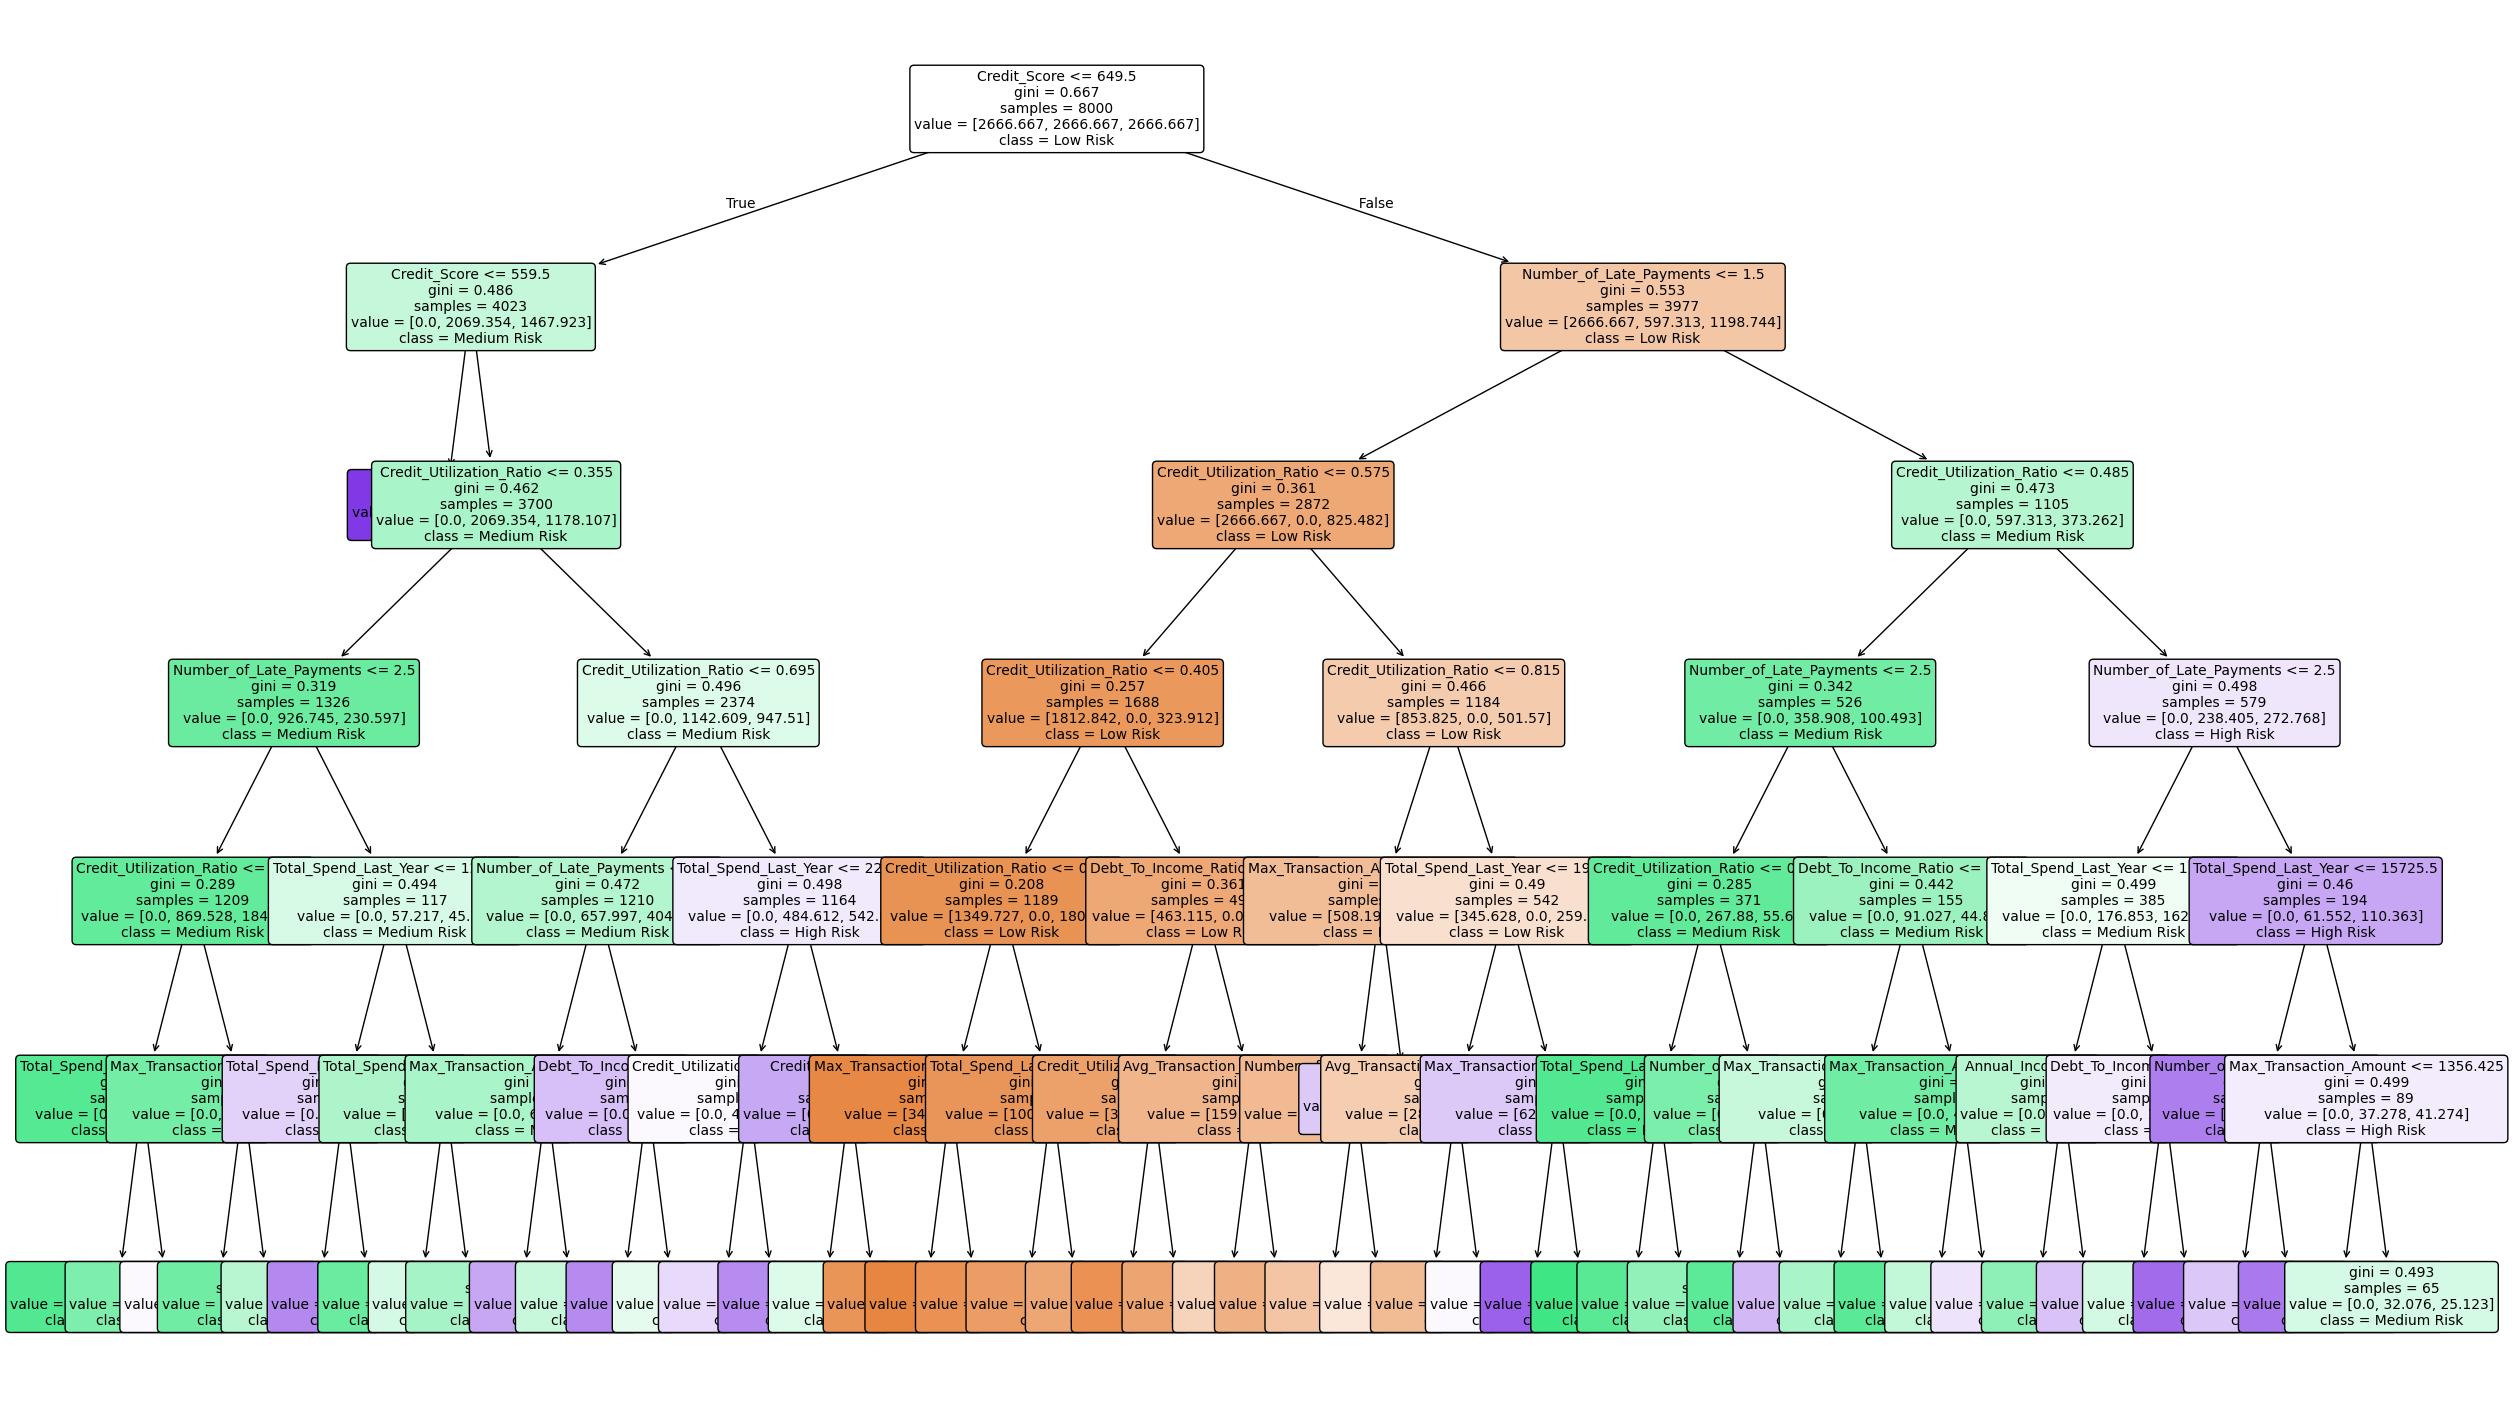

In [30]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 18))

tree.plot_tree(
    model,
    feature_names=X_train.columns,
    class_names=['Low Risk', 'Medium Risk', 'High Risk'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


In [31]:
for col, imp in zip(X.columns, model.feature_importances_):
    print(f"{col}: {round(imp, 3)}")


Annual_Income: 0.001
Credit_Score: 0.545
Number_of_Credit_Lines: 0.002
Credit_Utilization_Ratio: 0.113
Debt_To_Income_Ratio: 0.004
Number_of_Late_Payments: 0.311
Total_Spend_Last_Year: 0.012
Avg_Transaction_Amount: 0.003
Max_Transaction_Amount: 0.009


In [32]:
def validate_input(user):
    if user["annual_income"] <= 0:
        return "Income must be positive"

    if not (300 <= user["credit_score"] <= 900):
        return "Invalid credit score"

    if user["credit_limit"] <= 0:
        return "Invalid credit limit"

    if user["outstanding"] < 0:
        return "Outstanding cannot be negative"

    return "OK"


In [33]:
def derive_features(user):
    utilization = user["outstanding"] / user["credit_limit"]

    return {
        "Credit_Utilization_Ratio": utilization,
        "Number_of_Credit_Lines": user["cards"],
        "Number_of_Late_Payments": user["late_payments"]
    }


In [34]:
def rule_engine(user):
    traps = []

    utilization = user["outstanding"] / user["credit_limit"]

    if user["cash_withdrawal"] > 0:
        traps.append("Cash Withdrawal Trap")

    if user["payment_type"] == "minimum":
        traps.append("Minimum Due Trap")

    if utilization > 0.5:
        traps.append("High Credit Utilization Trap")

    if user["emi_active"]:
        traps.append("EMI Illusion Trap")

    if user["cards"] > 3:
        traps.append("Too Many Cards Trap")

    if user["late_payments"] > 0:
        traps.append("Missed Payment Trap")

    return traps


In [35]:
ml_features = [
    "Annual_Income",
    "Credit_Score",
    "Number_of_Credit_Lines",
    "Credit_Utilization_Ratio",
    "Debt_To_Income_Ratio",
    "Number_of_Late_Payments",
    "Total_Spend_Last_Year",
    "Avg_Transaction_Amount",
    "Max_Transaction_Amount"
]


In [36]:
user = {
    "annual_income": 800000,
    "credit_score": 620,
    "credit_limit": 200000,
    "outstanding": 120000,
    "cards": 4,
    "late_payments": 2,
    "emi_active": True,
    "payment_type": "minimum",
    "cash_withdrawal": 5000
}


In [37]:
def prepare_ml_input(user):
    utilization = user["outstanding"] / user["credit_limit"]

    return [[
        user["annual_income"],
        user["credit_score"],
        user["cards"],
        utilization,
        0.3,              # default DTI
        user["late_payments"],
        user["annual_income"] * 0.4,  # estimated spend
        user["annual_income"] / 120,
        user["annual_income"] / 12
    ]]


In [38]:
traps = rule_engine(user)
print("Detected Traps:", traps)


Detected Traps: ['Cash Withdrawal Trap', 'Minimum Due Trap', 'High Credit Utilization Trap', 'EMI Illusion Trap', 'Too Many Cards Trap', 'Missed Payment Trap']


In [39]:
risk_code = model.predict(prepare_ml_input(user))[0]

risk_label = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}[risk_code]
print("Overall Risk:", risk_label)


Overall Risk: High Risk


D:\ML\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


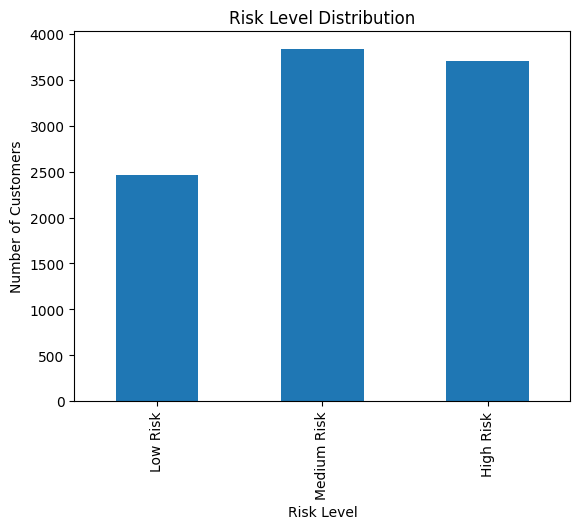

In [40]:
import matplotlib.pyplot as plt

risk_counts = y.value_counts().sort_index()

plt.figure()
risk_counts.plot(kind="bar")
plt.xticks([0,1,2], ["Low Risk", "Medium Risk", "High Risk"])
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.show()


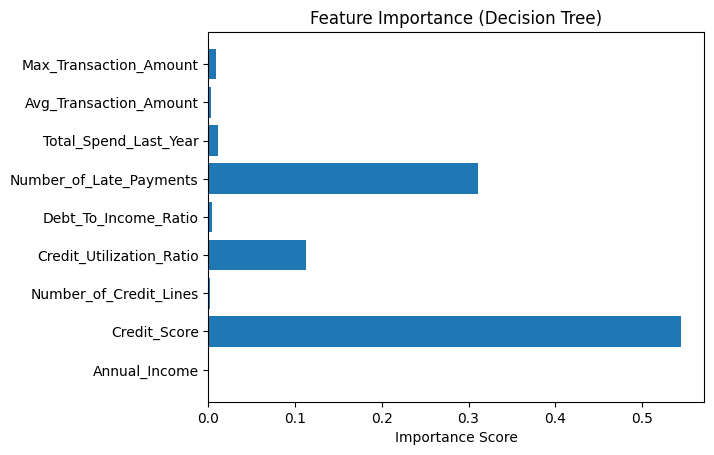

In [41]:
importances = model.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.xlabel("Importance Score")
plt.title("Feature Importance (Decision Tree)")
plt.show()


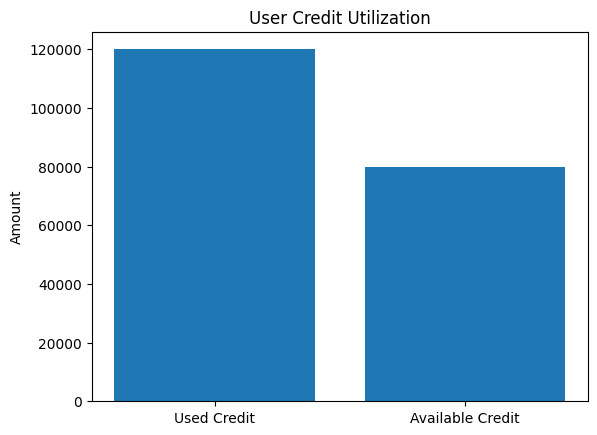

In [42]:
utilization = user["outstanding"] / user["credit_limit"]

plt.figure()
plt.bar(["Used Credit", "Available Credit"],
        [user["outstanding"], user["credit_limit"] - user["outstanding"]])
plt.title("User Credit Utilization")
plt.ylabel("Amount")
plt.show()


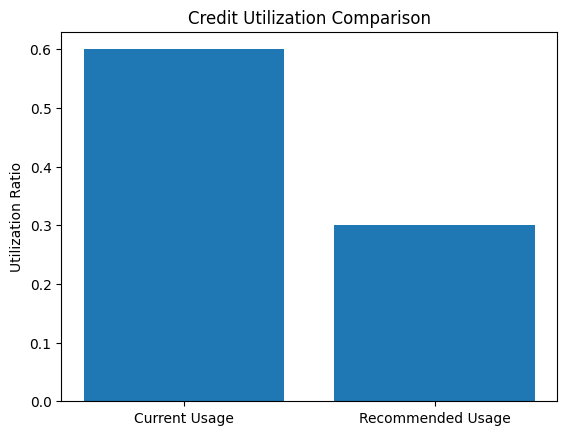

In [43]:
current_util = user["outstanding"] / user["credit_limit"]
safe_util = 0.3

plt.figure()
plt.bar(["Current Usage", "Recommended Usage"],
        [current_util, safe_util])
plt.title("Credit Utilization Comparison")
plt.ylabel("Utilization Ratio")
plt.show()
